<a href="https://colab.research.google.com/github/marioyramos/Challenge-Alura-Store/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **0. Importación de datos**



In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [17]:
tienda2.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Silla de oficina,Muebles,283600.0,15300.0,04/08/2021,Izabela de León,Medellín,1,Nequi,1,6.25184,-75.56359
1,Pandereta,Instrumentos musicales,76800.0,2300.0,26/11/2020,Blanca Ramirez,Medellín,3,Tarjeta de crédito,4,6.25184,-75.56359
2,Cama king,Muebles,443300.0,23800.0,22/10/2021,Izabela de León,Pereira,5,Tarjeta de crédito,10,4.81333,-75.69611
3,Cama king,Muebles,906200.0,46400.0,04/05/2022,Maria Alfonso,Cali,5,Tarjeta de crédito,10,3.43722,-76.52250
4,Silla de oficina,Muebles,397800.0,19400.0,26/02/2022,Lucas Olivera,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175


# **1. Análisis de facturación**



In [18]:
tienda1_Facturacion= tienda1['Precio'].sum()
tienda2_Facturacion= tienda2['Precio'].sum()
tienda3_Facturacion= tienda3['Precio'].sum()
tienda4_Facturacion= tienda4['Precio'].sum()

In [19]:
datos_factura = { 'Facturacion' : [tienda1_Facturacion, tienda2_Facturacion, tienda3_Facturacion, tienda4_Facturacion] }

df_factura = pd.DataFrame(datos_factura, index=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'])
df_factura


,Facturacion
Tienda 1,1.150880e+09
Tienda 2,1.116344e+09
Tienda 3,1.098020e+09
Tienda 4,1.038376e+09


In [20]:
type(tienda1_Facturacion)

numpy.float64

In [21]:
df_factura['Facturacion'] = df_factura['Facturacion'].astype(int)
df_factura

,Facturacion
Tienda 1,1150880400
Tienda 2,1116343500
Tienda 3,1098019600
Tienda 4,1038375700


# **2. Ventas por categoría**

In [22]:
tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [84]:
tienda1_venta_cat = tienda1.groupby('Categoría del Producto')[['Precio']].sum().sort_values('Precio', ascending=False)
tienda2_venta_cat = tienda2.groupby('Categoría del Producto')[['Precio']].sum().sort_values('Precio', ascending=False)
tienda3_venta_cat = tienda3.groupby('Categoría del Producto')[['Precio']].sum().sort_values('Precio', ascending=False)
tienda4_venta_cat = tienda4.groupby('Categoría del Producto')[['Precio']].sum().sort_values('Precio', ascending=False)

In [85]:
tienda1_venta_cat.head(10)

,Precio
Categoría del Producto,
Electrónicos,429493500.0
Electrodomésticos,363685200.0
Muebles,187633700.0
Instrumentos musicales,91299000.0
Deportes y diversión,39290000.0
Juguetes,17995700.0
Artículos para el hogar,12698400.0
Libros,8784900.0


In [25]:
tienda2_venta_cat.head(3)

,Precio
Categoría del Producto,
Electrónicos,410831100.0
Electrodomésticos,348567800.0
Muebles,176426300.0


In [26]:
tienda3_venta_cat.head(3)

,Precio
Categoría del Producto,
Electrónicos,410775800.0
Electrodomésticos,329237900.0
Muebles,201072100.0


In [27]:
tienda4_venta_cat.head(3)

,Precio
Categoría del Producto,
Electrónicos,409476100.0
Electrodomésticos,283260200.0
Muebles,192528900.0


# **3. Calificación promedio de la tienda**


In [28]:
tienda1_califica_prom = tienda1['Calificación'].mean()
tienda2_califica_prom = tienda2['Calificación'].mean()
tienda3_califica_prom = tienda3['Calificación'].mean()
tienda4_califica_prom = tienda4['Calificación'].mean()

In [29]:
tienda2_califica_prom

np.float64(4.037303942348453)

In [56]:
datos_califica = {'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
                  'Calificacion Promedio' : [tienda1_califica_prom, tienda2_califica_prom, tienda3_califica_prom, tienda4_califica_prom]

                  }

df_califica = pd.DataFrame(datos_califica, index=['T1', 'T2', 'T3', 'T4'])
df_califica

,Tienda,Calificacion Promedio
T1,Tienda 1,3.976685
T2,Tienda 2,4.037304
T3,Tienda 3,4.048326
T4,Tienda 4,3.995759


# **4. Productos más y menos vendidos**

In [31]:
tienda1.head(20)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
5,Bloques de construcción,Juguetes,24200.0,0.0,03/12/2020,Beatriz Morales,Cali,5,Cupón,1,3.43722,-76.52250
6,Muñeca bebé,Juguetes,44200.0,0.0,07/08/2021,Juan Fernandez,Bogotá,3,Nequi,1,4.60971,-74.08175
7,Lavavajillas,Electrodomésticos,1189700.0,63700.0,18/06/2021,Felipe Santos,Santa Marta,5,Tarjeta de crédito,10,11.24079,-74.19904
8,Lavadora de ropa,Electrodomésticos,1518200.0,79000.0,08/01/2022,Izabela de León,Bogotá,1,Tarjeta de crédito,5,4.60971,-74.08175
9,Carrito de control remoto,Juguetes,75200.0,5100.0,24/02/2020,Beatriz Morales,Bogotá,5,Nequi,1,4.60971,-74.08175


In [32]:
producto_conteo1 = tienda1['Producto'].value_counts()
producto_conteo1.head(3)


,count
Producto,
Microondas,60
TV LED UHD 4K,60
Armario,60


In [33]:
producto_conteo1.tail(3)

,count
Producto,
Olla de presión,35
Auriculares con micrófono,33
Celular ABXY,33


In [34]:
producto_conteo2 = tienda2['Producto'].value_counts()
producto_conteo2.head(3)

,count
Producto,
Iniciando en programación,65
Microondas,62
Batería,61


In [35]:
producto_conteo2.tail(3)

,count
Producto,
Mesa de comedor,34
Impresora,34
Juego de mesa,32


In [36]:
producto_conteo3 = tienda3['Producto'].value_counts()
producto_conteo3.head(3)

,count
Producto,
Kit de bancas,57
Mesa de comedor,56
Cama king,56


In [37]:
producto_conteo3.tail(3)

,count
Producto,
Mochila,36
Microondas,36
Bloques de construcción,35


In [38]:
producto_conteo4 = tienda4['Producto'].value_counts()
producto_conteo4.head(3)

,count
Producto,
Cama box,62
Cubertería,59
Dashboards con Power BI,56


In [39]:
producto_conteo4.tail(3)

,count
Producto,
Guitarra acústica,37
Armario,34
Guitarra eléctrica,33


# **5. Envío promedio por tienda**

In [40]:
tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [41]:
tienda1_costoenvio_prom = tienda1['Costo de envío'].mean()
tienda2_costoenvio_prom = tienda2['Costo de envío'].mean()
tienda3_costoenvio_prom = tienda3['Costo de envío'].mean()
tienda4_costoenvio_prom = tienda4['Costo de envío'].mean()

In [42]:
datos_costoenvio = { 'Costo Promedio de envío' : [tienda1_costoenvio_prom, tienda2_costoenvio_prom, tienda3_costoenvio_prom, tienda4_costoenvio_prom] }

df_costoenvio = pd.DataFrame(datos_costoenvio, index=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'])
df_costoenvio

,Costo Promedio de envío
Tienda 1,26018.609580
Tienda 2,25216.235693
Tienda 3,24805.680373
Tienda 4,23459.457167


# **6. Generando gráfico**

## **6.1 Grafico de facturacion**

In [43]:
df_factura

,Facturacion
Tienda 1,1150880400
Tienda 2,1116343500
Tienda 3,1098019600
Tienda 4,1038375700


<Axes: >

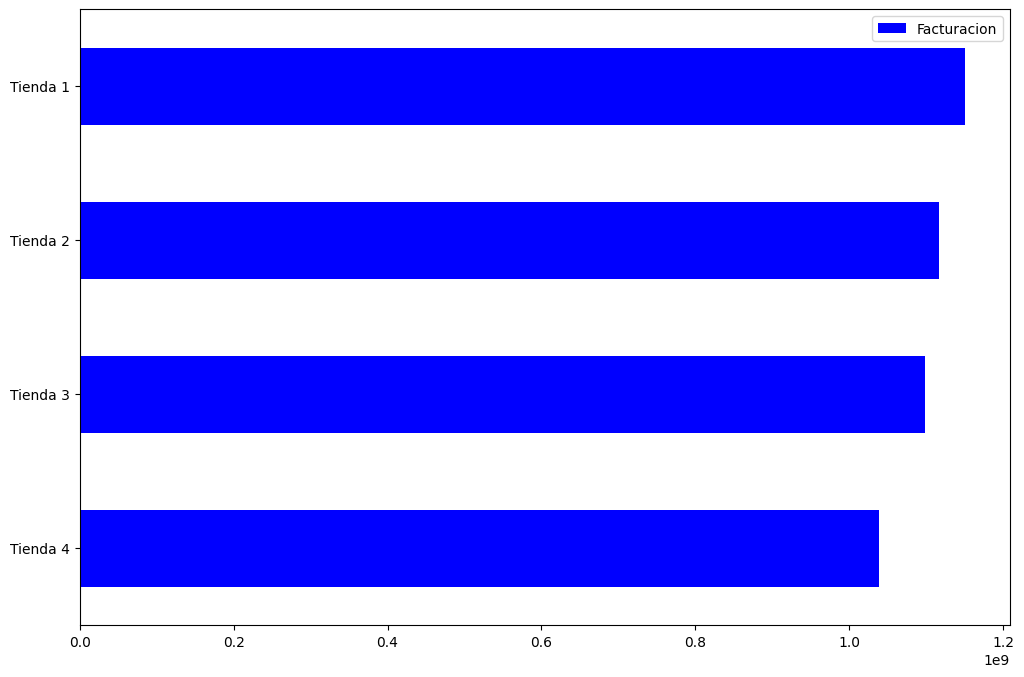

In [47]:

df = df_factura.sort_values('Facturacion', ascending=True)
df.plot(kind='barh', figsize=(12,8), color='blue')


## **6.2 Grafico de Categorias de productos**

In [86]:
import pandas as pd
tienda1_venta_cat['Productos'] = tienda1_venta_cat.index
tienda1_venta_cat.head()

,Precio
Categoría del Producto,
Electrónicos,429493500.0
Electrodomésticos,363685200.0
Muebles,187633700.0
Instrumentos musicales,91299000.0
Deportes y diversión,39290000.0


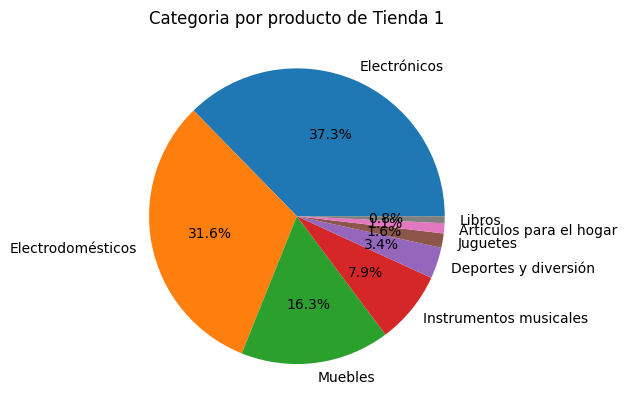

In [88]:
    import matplotlib.pyplot as plt

    tienda1_venta_cat.plot.pie(y='Precio', labels=tienda1_venta_cat['Productos'], autopct='%1.1f%%', legend=False)
    plt.title('Categoria por producto de Tienda 1')
    plt.ylabel('') # Hide the y-axis label for cleaner appearance
    plt.show()

In [89]:
import pandas as pd
tienda2_venta_cat['Productos'] = tienda2_venta_cat.index
tienda2_venta_cat.head()

,Precio,Productos
Categoría del Producto,,
Electrónicos,410831100.0,Electrónicos
Electrodomésticos,348567800.0,Electrodomésticos
Muebles,176426300.0,Muebles
Instrumentos musicales,104990300.0,Instrumentos musicales
Deportes y diversión,34744500.0,Deportes y diversión


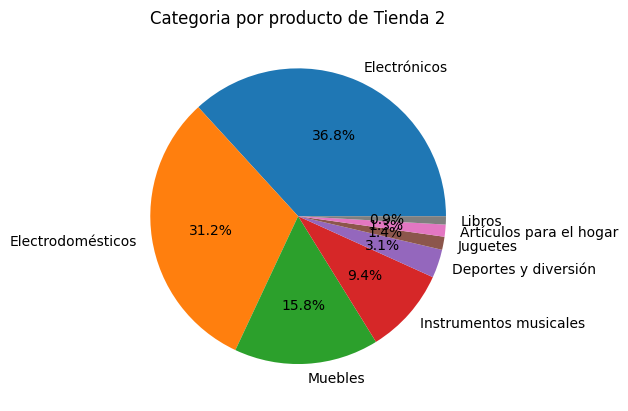

In [90]:
    import matplotlib.pyplot as plt

    tienda2_venta_cat.plot.pie(y='Precio', labels=tienda2_venta_cat['Productos'], autopct='%1.1f%%', legend=False)
    plt.title('Categoria por producto de Tienda 2')
    plt.ylabel('') # Hide the y-axis label for cleaner appearance
    plt.show()

In [91]:
import pandas as pd
tienda3_venta_cat['Productos'] = tienda3_venta_cat.index
tienda3_venta_cat.head()

,Precio,Productos
Categoría del Producto,,
Electrónicos,410775800.0,Electrónicos
Electrodomésticos,329237900.0,Electrodomésticos
Muebles,201072100.0,Muebles
Instrumentos musicales,77380900.0,Instrumentos musicales
Deportes y diversión,35593100.0,Deportes y diversión


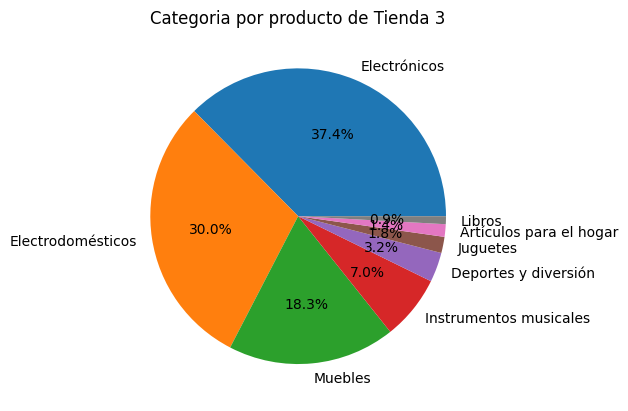

In [92]:
    import matplotlib.pyplot as plt

    tienda3_venta_cat.plot.pie(y='Precio', labels=tienda3_venta_cat['Productos'], autopct='%1.1f%%', legend=False)
    plt.title('Categoria por producto de Tienda 3')
    plt.ylabel('') # Hide the y-axis label for cleaner appearance
    plt.show()

In [93]:
import pandas as pd
tienda4_venta_cat['Productos'] = tienda4_venta_cat.index
tienda4_venta_cat.head()

,Precio,Productos
Categoría del Producto,,
Electrónicos,409476100.0,Electrónicos
Electrodomésticos,283260200.0,Electrodomésticos
Muebles,192528900.0,Muebles
Instrumentos musicales,75102400.0,Instrumentos musicales
Deportes y diversión,33350100.0,Deportes y diversión


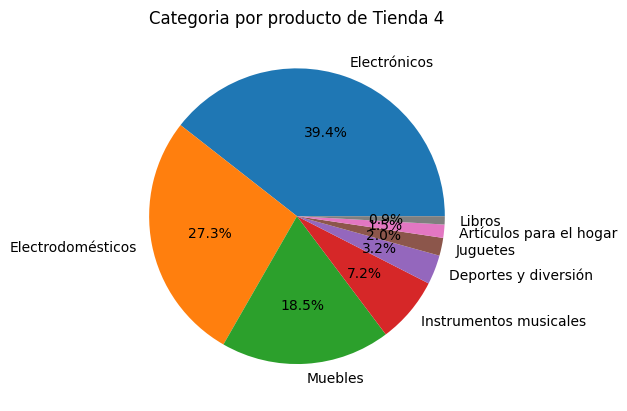

In [94]:
    import matplotlib.pyplot as plt

    tienda4_venta_cat.plot.pie(y='Precio', labels=tienda4_venta_cat['Productos'], autopct='%1.1f%%', legend=False)
    plt.title('Categoria por producto de Tienda 4')
    plt.ylabel('') # Hide the y-axis label for cleaner appearance
    plt.show()

## **6.3 Calificación promedio de la tienda**

In [95]:
df_califica.head()

,Tienda,Calificacion Promedio
T1,Tienda 1,3.976685
T2,Tienda 2,4.037304
T3,Tienda 3,4.048326
T4,Tienda 4,3.995759


<Axes: >

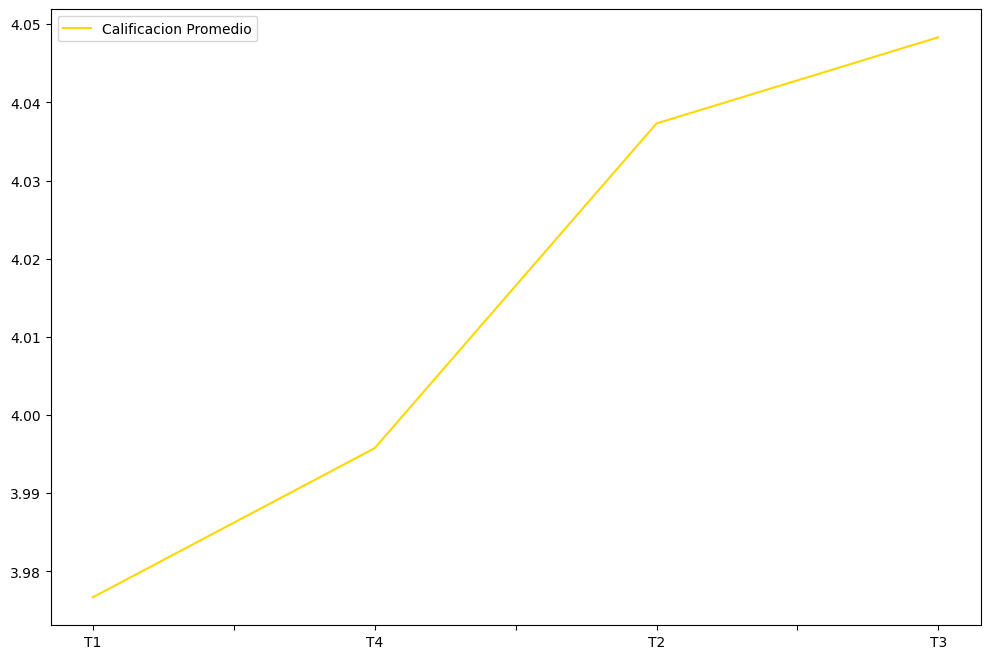

In [99]:
df = df_califica.sort_values('Calificacion Promedio', ascending=True)
df.plot(kind='line', figsize=(12,8), color='gold')

## **6.4 Costo de Envío**

In [100]:
df_costoenvio.head()

,Costo Promedio de envío
Tienda 1,26018.609580
Tienda 2,25216.235693
Tienda 3,24805.680373
Tienda 4,23459.457167


<Axes: >

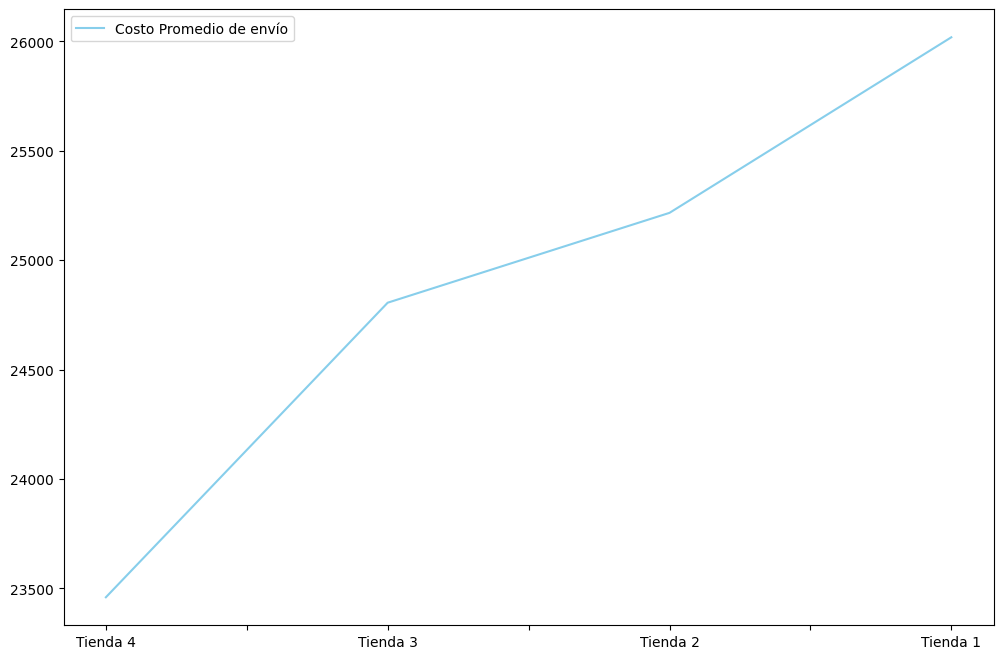

In [102]:
df = df_costoenvio.sort_values('Costo Promedio de envío', ascending=True)
df.plot(kind='line', figsize=(12,8), color='skyblue')

# **Analisis de resultados**

###
El análisis de desempeño comercial evidencia que la Tienda 4 presenta el menor nivel de ventas durante el periodo evaluado, registrando un 9 % menos de ingresos en comparación con la Tienda 1. Asimismo, se observa que el 66 % de las ventas totales se concentra en las categorías de Eléctricos y Electrodomésticos, lo que refleja una alta dependencia de estos segmentos.

En cuanto a la satisfacción del cliente, las calificaciones promedio de las tiendas muestran valores similares; sin embargo, las Tiendas 4 y 1 ocupan el tercer y cuarto lugar, respectivamente, dentro del ranking general. Un hallazgo relevante es que, en las Tiendas 3 y 4, a pesar de que las categorías con mayor facturación son Eléctricos y Electrodomésticos, los productos más vendidos corresponden a Kit de Bancas y Cama Box, respectivamente. Esta situación evidencia una inconsistencia entre la categoría predominante y los productos con mayor rotación, lo que podría reflejar una estrategia comercial poco alineada o una segmentación de productos ineficiente.

Por otro lado, el costo promedio de envío es menor en las Tiendas 3 y 4, lo que se asocia a un volumen de ventas inferior, indicando una posible correlación inversa entre ventas y costo unitario logístico.

Con base en estos resultados, se recomienda al Sr. Juan evaluar el cierre o reestructuración de la Tienda 4, dado que presenta menor rentabilidad, baja consistencia en su portafolio de productos y un modelo de ventas que podría comprometer su sostenibilidad en el mediano plazo.